**1.Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2.Load the dataset**

In [2]:
df = pd.read_csv(r"C:\Users\pranj\Downloads\student_performance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

**3. Create an average score**

We'll use the three subject scores:

* Math
* Reading
* Writing

In [5]:
df["average score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


**4. Multivariable Visualization 1**

 (math + reading + writing together)

* Analyzing 3 variables simultaneously.

    X-axis       → Math score

    Y-axis       → Reading score

    Bubble size  → Writing score

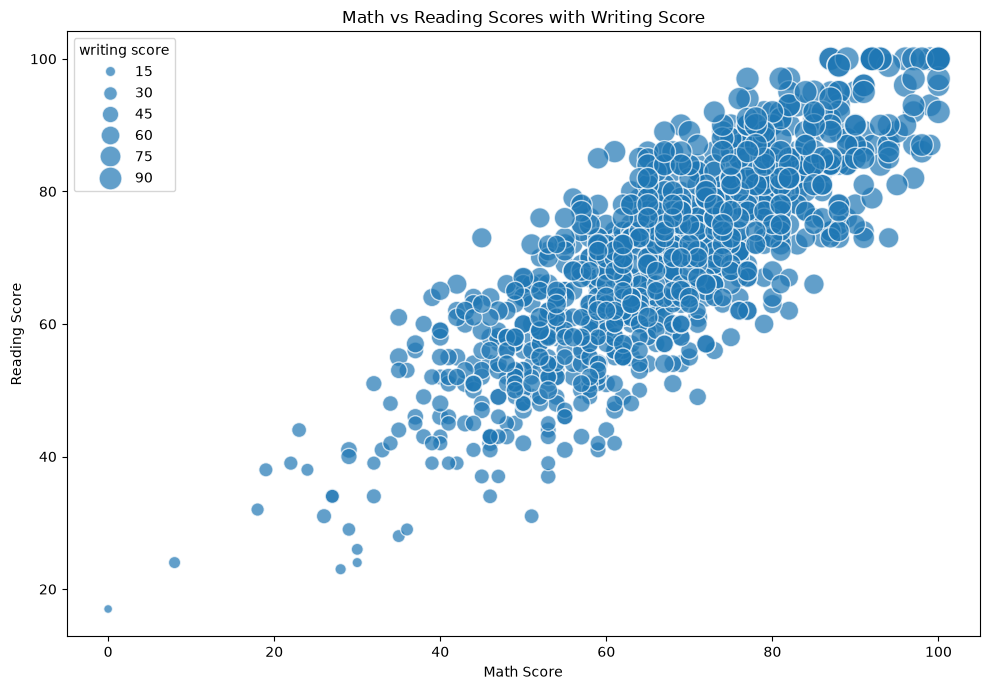

In [6]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="math score",
    y="reading score",
    size="writing score",
    sizes=(40, 300),
    alpha=0.7
)

plt.title("Math vs Reading Scores with Writing Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.tight_layout()
plt.show()

**5. Multivariable Visualization-2**

Test preparation + Subject + Score

i) First reshape the data:

In [7]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

melted_df = df.melt(
    id_vars="test preparation course",
    value_vars=score_columns,
    var_name="Subject",
    value_name="Score"
)

melted_df.head()

,test preparation course,Subject,Score
0,none,math score,72
1,completed,math score,69
2,none,math score,90
3,none,math score,47
4,none,math score,76


ii) Then create the visualization:

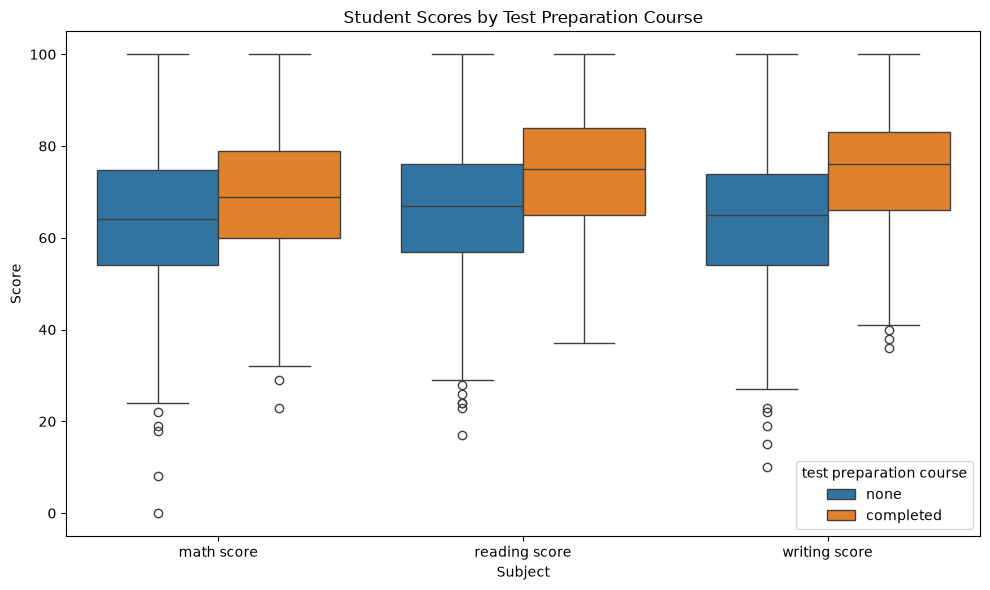

In [8]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=melted_df,
    x="Subject",
    y="Score",
    hue="test preparation course"
)

plt.title("Student Scores by Test Preparation Course")
plt.xlabel("Subject")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

****6. Multivariable Visualization-3****

Gender + Subject + Score

In [9]:
gender_scores = df.melt(
    id_vars="gender",
    value_vars=[
        "math score",
        "reading score",
        "writing score"
    ],
    var_name="Subject",
    value_name="Score"
)

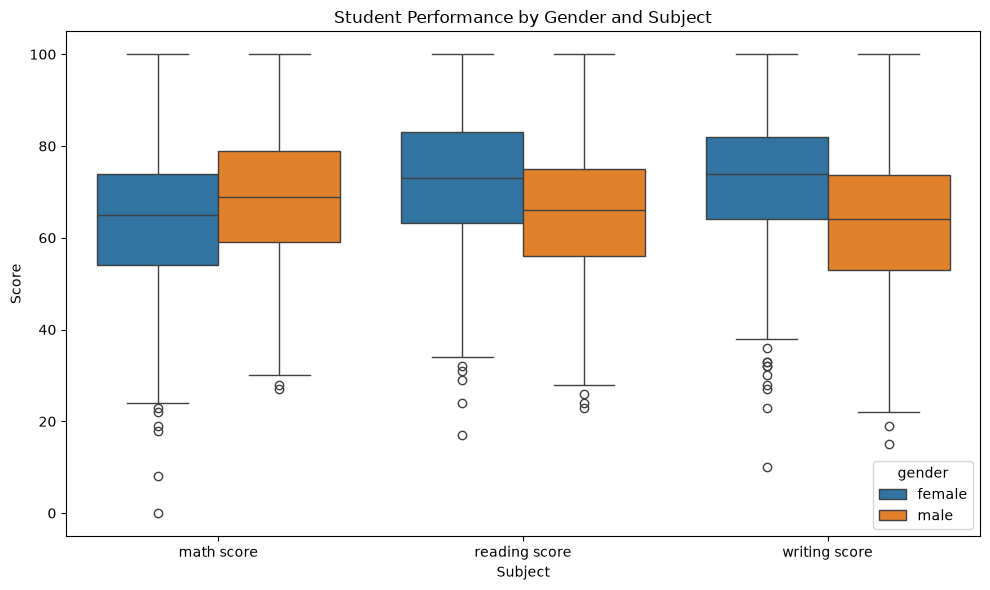

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=gender_scores,
    x="Subject",
    y="Score",
    hue="gender"
)

plt.title("Student Performance by Gender and Subject")
plt.xlabel("Subject")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

## Multivariate Analysis Findings

### 1. Subject Performance Relationships

The scatter plot examines the relationship between math and reading
scores while representing writing score through bubble size. This
provides a three-variable view of student performance.

### 2. Test Preparation and Performance

The box plot compares math, reading, and writing score distributions
across test preparation groups. It helps identify differences in
performance distributions between the groups.

### 3. Gender and Subject Performance

The grouped box plot compares score distributions across subjects and
gender, providing a multivariable view of student performance.

### Overall

The visualizations demonstrate how multiple variables can be analyzed
together to identify patterns and relationships within the student
performance dataset.